<a href="https://colab.research.google.com/github/tranquoctruong2503/THUCHANH_DEEPLEARNING/blob/main/ThucHanhBuoi02_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Nap thu vien
!pip install scikeras

# Install required libraries
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# TensorFlow & Keras
import tensorflow as tf
import keras
# Keras model
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout

from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler


In [19]:
# Doc tap du lieu
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_tets) = fashion.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_tets.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [20]:
# Xu ly du lieu
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)

minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))


Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


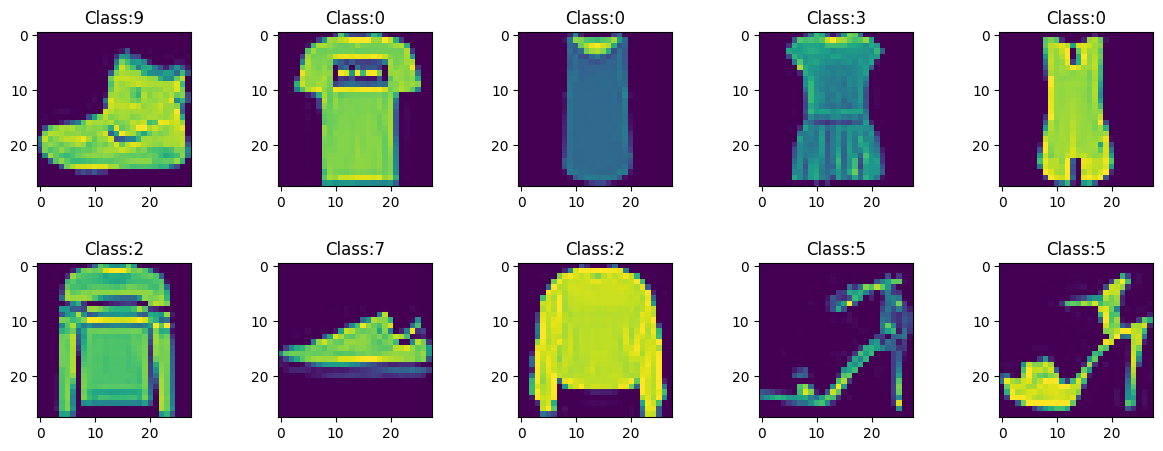

In [21]:
# Truc quan hoa du lieu
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for  i in range (10):
  ax[i].imshow(X_train[i].reshape(28,28))
  ax[i].title.set_text('Class:'+str(y_train[i]))

plt.subplots_adjust(hspace=0.5)
plt.show()

In [22]:
# Xay dung mo hinh hoc ANN
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huan luyen ANN model
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1616/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9413 - loss: 0.1564

In [ ]:
# Danh gia ANN model
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [ ]:
# Du bao anh moi
print(np.argmax(fashion_model.predict(X_test)[0]), y_tets[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_tets[10])

In [ ]:
# Doc tap du lieu tu file
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'

mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print(mnist_train.shape)
print(mnist_train.head())

In [12]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of class:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(19999, 784)
Number of class: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
import tensorflow as tf
import keras
from keras  import Sequential
from keras.layers import Dense

model = Sequential()

model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

In [ ]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)
print (np.argmax(model.predict(X_test)[0]), y_test[0])

In [ ]:
img_size =(28,28)
img = tf.keras.preprocessing.image.load_img(
    'content/sample_data/dress.jpg', color_mode="grayscale", target_size=img_size)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img= np.reshape(img_array, (784))
img_array= tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)

score = np.argmax(img_predict)
print(score)